<h2 style="color:blue" align="center">Handwritten digits classification using CNN</h2>

In this notebook we will classify handwritten digits using a simple neural network (ANN) first and than repeat same thing with convolutional neural network. We will see how accuracy improves clickly when you use convolutional neural network.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

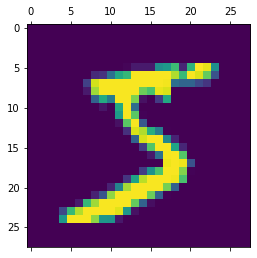

In [6]:
plt.matshow(X_train[0])

In [7]:
y_train[0]

5

In [8]:
X_train = X_train / 255
X_test = X_test / 255

<h3 style='color:purple'>Using ANN for classification</h3>

In [9]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])



In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [12]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2726 - accuracy: 0.9218
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1245 - accuracy: 0.9629
Epoch 3/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0861 - accuracy: 0.9745
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0662 - accuracy: 0.9797
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0512 - accuracy: 0.9840
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0418 - accuracy: 0.9869
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0344 - accuracy: 0.9889
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0271 - accuracy: 0.9920
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0230 - accuracy: 0.9929
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.017

In [13]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0764 - accuracy: 0.9785


[0.0763716995716095, 0.9785000085830688]

In [14]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [15]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

<h3 style='color:purple'>Using CNN for classification</h3>

In [30]:
model = keras.Sequential([
    
    layers.Conv2D(30,(3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
 
    #layers.Conv2D(40,(3,3), activation='relu'),
    #layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [31]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 26, 26, 30)        300       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 13, 13, 30)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 11, 11, 40)        10840     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 5, 5, 40)         0         
 g2D)                                                            
                                                                 
 flatten_7 (Flatten)         (None, 1000)              0         
                                                                 
 dense_14 (Dense)            (None, 100)              

In [21]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 43s 22ms/step - loss: 0.0138 - accuracy: 0.9951
Epoch 2/5
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0091 - accuracy: 0.9970
Epoch 3/5
1875/1875 [==============================] - 41s 22ms/step - loss: 0.0073 - accuracy: 0.9974
Epoch 4/5
1875/1875 [==============================] - 41s 22ms/step - loss: 0.0055 - accuracy: 0.9981
Epoch 5/5
1875/1875 [==============================] - 37s 20ms/step - loss: 0.0050 - accuracy: 0.9984


In [22]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [23]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 3s 8ms/step - loss: 0.0608 - accuracy: 0.9850


[0.06079578772187233, 0.9850000143051147]